In [1]:
import torch
import numpy as np
import pandas as pd
from torch import nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import ScalingLaw, GetAsymptVar, SampleAlpha
from constants import lower_bounds, test_models, delete_models, Y_names_tidy, Y_names
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Plots
colormap = "coolwarm" 
fontsize = 13

# Data
names = {0:"Open LLM Leaderboard v1/v2", 1:"Open LLM Leaderboard v1",2:"Open LLM Leaderboard v2"}

eps = 1e-3

# Model specification
Ks = [1,2,3,4,5,6,7,8,9,10,11,12]

# Model fitting
B = 10000
lrs = [.1,.05,.01]
scheduler_factors = [.999,.99]
reps = 5
n_epochs = 20000
random_seed = 42
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def numpy_to_latex_table(
    estimates: np.ndarray,
    std_errors: np.ndarray,
    row_labels: list = None,
    col_names: list = None,
    float_format: str = "%.2f"
) -> str:
    r"""
    Generate a LaTeX table from two 2D NumPy arrays: one of estimates and one of standard errors.
    The standard errors are shown in parentheses below their corresponding estimates.
    Uses \multirow to centralize row labels over the estimate/SE pair.
    Optionally includes column names as a header row.

    Parameters:
    - estimates (np.ndarray): 2D array of point estimates.
    - std_errors (np.ndarray): 2D array of standard errors, same shape as estimates.
    - row_labels (list, optional): List of labels (str) for each row of estimates. Length must match number of rows.
                                   If provided, each label is placed using \multirow{2}{*}{label}.
    - col_names (list, optional): List of column header names (str) for each estimate column. Length must match number of columns.
    - float_format (str): Format string for floats, default is two decimal places.

    Returns:
    - str: A string containing the LaTeX code for the table. Requires \usepackage{multirow} and \usepackage{booktabs}.
    """
    if estimates.shape != std_errors.shape:
        raise ValueError("Estimates and standard errors must have the same shape.")

    n_rows, n_cols = estimates.shape

    if row_labels is not None:
        if len(row_labels) != n_rows:
            raise ValueError("Length of row_labels must match number of rows in estimates.")
    if col_names is not None:
        if len(col_names) != n_cols:
            raise ValueError("Length of col_names must match number of columns in estimates.")

    # Begin LaTeX table
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"% Requires \usepackage{booktabs} and \usepackage{multirow}")

    # Build column format: one 'c' for each column, plus one 'c' for row_labels if provided
    if row_labels is not None:
        col_format = "c " + " ".join(["c"] * n_cols)
    else:
        col_format = " ".join(["c"] * n_cols)
    latex.append(r"\begin{tabular}{" + col_format + r"}")
    latex.append(r"\toprule")

    # Header row if column names are provided
    if col_names is not None:
        if row_labels is not None:
            header = " & " + " & ".join(col_names) + r" \\"
        else:
            header = " & ".join(col_names) + r" \\"
        latex.append(header)
        latex.append(r"\midrule")

    for i in range(n_rows):
        # Estimate row with multirow label (if provided)
        if row_labels is not None:
            est_line = (
                r"\multirow{2}{*}{" + row_labels[i] + "} & " +
                " & ".join(float_format % est for est in estimates[i, :]) +
                r" \\"
            )
        else:
            est_line = " & ".join(float_format % est for est in estimates[i, :]) + r" \\"
        latex.append(est_line)

        # Std error row (blank first cell if label provided)
        if row_labels is not None:
            se_line = " & " + " & ".join(f"({float_format % se})" for se in std_errors[i, :]) + r" \\"
        else:
            se_line = " & ".join(f"({float_format % se})" for se in std_errors[i, :]) + r" \\"
        latex.append(se_line)

        if i < n_rows - 1:
            latex.append(r"\midrule")

    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\caption{Insert your caption here.}")
    latex.append(r"\label{tab:insert_label_here}")
    latex.append(r"\end{table}")

    return "\n".join(latex)

In [2]:
!nvidia-smi

Mon May 18 01:07:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:AE:00.0 Off |                  N/A |
| 35%   52C    P5             34W /  575W |       4MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data

In [3]:
dfs = {}
dfs[1] = pd.read_csv('data/df_full_v1.csv').drop('Unnamed: 0', axis=1)
dfs[2] = pd.read_csv('data/df_full_v2.csv').drop('Unnamed: 0', axis=1)
dfs[0] = pd.merge(dfs[1], dfs[2], on=['model', 'family', 'size', 'tokens', 'flops'], how='outer')
dfs[0].shape, dfs[1].shape, dfs[2].shape

((286, 17), (168, 11), (216, 11))

In [4]:
for i in range(3):
    print(i,len(set(dfs[i].model)),len(set(dfs[i].family)))

0 285 170
1 168 75
2 215 146


In [5]:
Ys = {}
Xs = {}
Ds = {}
Cs = {}
mus = {}
stds = {}

for j in Y_names.keys():
    Ys[j] = np.array(dfs[j].loc[:,Y_names[j]])
    Ys[j] = np.clip(Ys[j], a_min=eps, a_max=1-eps)
        
    X = np.log(np.array(dfs[j].loc[:,['size','tokens']]))
    Xs[j] = np.hstack((X,(X[:,0]*X[:,1])[:,None]))
    mus[j] = Xs[j].mean(0)
    stds[j] = Xs[j].std(0)
    Xs[j] = (Xs[j]-mus[j])/stds[j] #standardization is not supposed to change the solution and that's why we do not care a lot abt data splitting
    
    Ds[j] = np.array(pd.get_dummies(dfs[j].family)).astype(int)

    Cs[j] = np.array([lower_bounds[s] for s in Y_names[j]]).reshape((1,-1))

## Model fitting

In [ ]:
j = 0 #we just care about the full data

In [ ]:
models = {}
for k in Ks:
    models[k] = ScalingLaw(k)
    models[k].fit(Xs[j],
                  Ys[j],
                  Ds[j],
                  Cs[j],
                  B = B,
                  lrs = lrs,
                  scheduler_factors = scheduler_factors,
                  reps = reps,
                  n_epochs = n_epochs,    
                  verbose = False,
                  device = device)
    
    np.save(f"models/models_{j}.npy",models)

## Plots

In [7]:
models = {0: np.load(f"models/models_0.npy", allow_pickle=True).item()}

### AIC

In [ ]:
j = 0

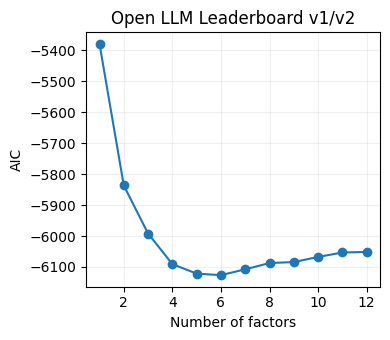

In [8]:
aic = [m.aic for m in models[j].values()]

fig, axes = plt.subplots(1, 1, figsize=(4, 3.5))

axes.plot(list(range(1,13)), aic, marker='o')
axes.set_title(names[0])
axes.set_xlabel('Number of factors')
axes.set_ylabel('AIC')
axes.grid(True,alpha=.2)

plt.tight_layout()
plt.savefig(f'plots/aic.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Correlations and loadings

In [9]:
j = 0 

In [10]:
K_opt = {0:4}

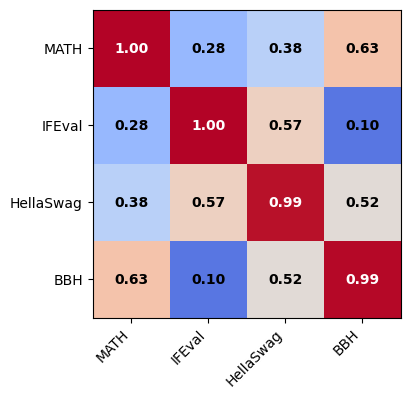

In [11]:
vmin=0
vmax=1

k = K_opt[j]
d = k
model = models[j][k]
Sigma = model.sigma
factor_labels=[Y_names_tidy[s] for s in Y_names[j]][:k]

plt.figure(figsize=(d,d))  # Set the figure size (width, height) in inches
plt.imshow(Sigma, cmap=colormap, vmin=vmin, vmax=vmax)
plt.xticks(np.arange(d), labels=factor_labels, rotation=45, ha="right")  # Set the x-tick labels
plt.yticks(np.arange(d), labels=factor_labels, rotation=0, ha="right")  # Set the y-tick labels

threshold = .8
for i in range(len(Sigma)):
    for jj in range(len(Sigma.T)):
        value = Sigma[i, jj]
        color = "black" if value < threshold else "white"  # Conditional color
        text = plt.text(jj, i, f'{value:.2f}', size=10, ha="center", va="center", color=color, weight='bold')#

plt.savefig(f'plots/skills-correlation_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

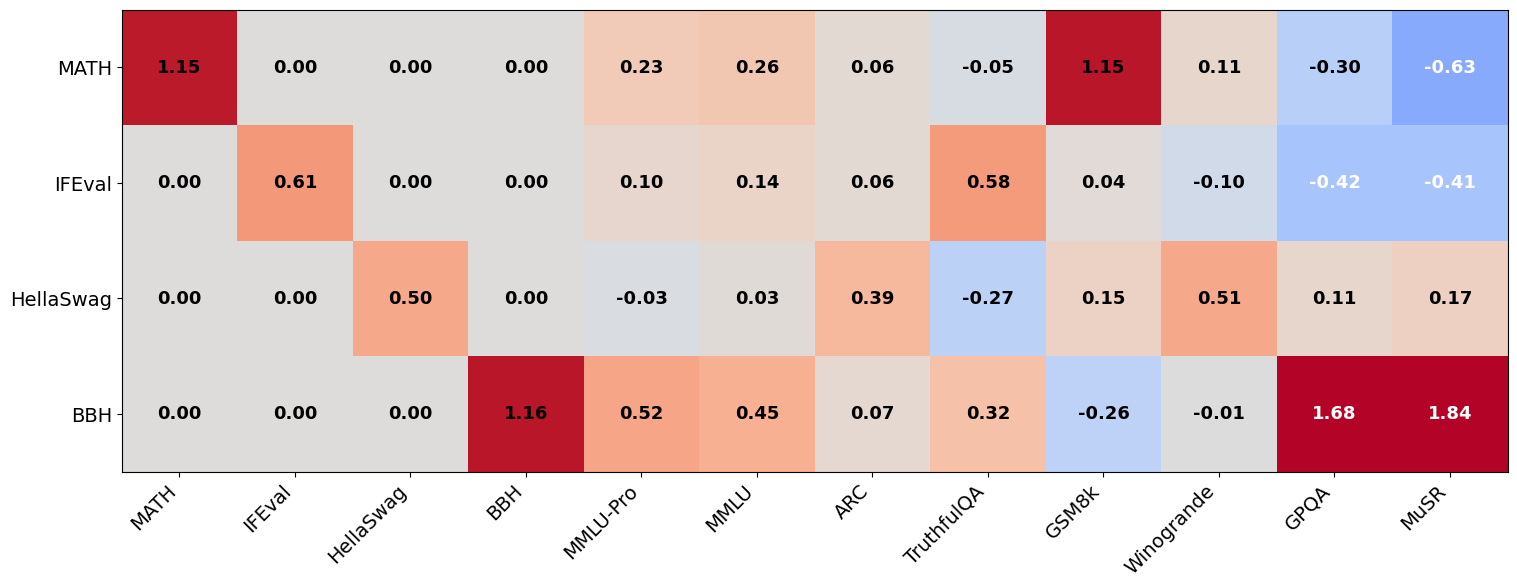

In [12]:
vmin=-1.2#None
vmax=1.2#None

k = K_opt[j]
model = models[j][k]
L_rot = model.lambd

plt.figure(figsize=((10/6)*L_rot.shape[1], (6/4)*k))  # Set the figure size (width, height) in inches
plt.imshow(L_rot, cmap=colormap, vmin=vmin, vmax=vmax)
plt.xticks(np.arange(len(Y_names[j])), labels=[Y_names_tidy[s] for s in Y_names[j]], size=fontsize+1, rotation=45, ha="right")  # Set the x-tick labels
plt.yticks(np.arange(k), labels=[Y_names_tidy[s] for s in Y_names[j]][:k], size=fontsize+1, rotation=0, ha="right")  # Set the y-tick labels

inter = [-.3,1.6]
for i in range(len(L_rot)):
    for jj in range(len(L_rot.T)):
        value = L_rot[i, jj]
        color = "black" if value > inter[0] and  value < inter[1] else "white"  # Conditional color
        text = plt.text(jj, i, f'{value:.2f}', size=fontsize, ha="center", va="center", color=color, weight='bold')#

plt.savefig(f'plots/loadings_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Confidence intervals for beta

In [13]:
j=0

In [ ]:
%%time
Ss = {}
Ss[j] = GetAsymptVar(Xs[j], Ys[j], Ds[j], Cs[j], models[j][K_opt[j]], K_opt[j], B=3*B)
np.save("data/stes.npy",Ss)

fine-tuning:   0%|          | 0/100000 [00:00<?, ?it/s]

grad norm: 151.03643798828125
grad norm: 61.21796798706055
grad norm: 44.30878829956055
grad norm: 31.861499786376953
grad norm: 22.145553588867188
grad norm: 14.644915580749512
grad norm: 9.074322700500488
grad norm: 7.669935703277588
grad norm: 2.8880865573883057
grad norm: 0.6456703543663025
grad norm: 0.41067400574684143
grad norm: 0.3953167498111725
grad norm: 0.3609794080257416
grad norm: 0.3683844804763794
grad norm: 0.35854285955429077
grad norm: 0.3182830512523651
grad norm: 0.3226472735404968
grad norm: 0.2793501019477844
grad norm: 0.27202993631362915
grad norm: 0.2603425085544586
grad norm: 0.24965940415859222
grad norm: 0.24747765064239502
grad norm: 0.239497110247612
grad norm: 0.2386915385723114
grad norm: 0.22449372708797455
grad norm: 0.21785685420036316
grad norm: 0.21244946122169495
grad norm: 0.21091535687446594
grad norm: 0.20633603632450104
grad norm: 0.20032978057861328
grad norm: 0.19947490096092224
grad norm: 0.19651706516742706
grad norm: 0.1925213485956192
gr

In [ ]:
Ss = np.load("data/stes.npy", allow_pickle=True).item()

In [ ]:
labels = ['log(s)', 'log(t)', 'log(s)log(t)']

In [ ]:
print(numpy_to_latex_table(models[j][K_opt[j]].beta/stds[j][:,None],
                           Ss[j]['H'][1]['beta_ste']/stds[j][:,None], float_format="%.3f", row_labels=labels, col_names=[f"Factor {f+1}" for f in range(K_opt[j])]))

In [ ]:
print(numpy_to_latex_table(models[j][K_opt[j]].beta/stds[j][:,None],
                           Ss[j]['J'][1]['beta_ste']/stds[j][:,None], float_format="%.3f", row_labels=labels, col_names=[f"Factor {f+1}" for f in range(K_opt[j])]))

## Family comparison

In [23]:
j = 0
K = K_opt[j]

In [24]:
cov = np.load("data/stes.npy", allow_pickle=True).item()
cov = cov[j][0][0]['V']

beta = models[j][K].beta
b = models[j][K].b
phi = models[j][K].phi
lambd1, lambd2 = np.diag(models[j][K].lambd[:,:K]), models[j][K].lambd[:,K:]
sigma = models[j][K].sigma

In [25]:
family_names = np.array(pd.get_dummies(dfs[j].family).columns)

f1='yi-1.5'
f2='yi-1.5-chat'
fs = [np.argmax(family_names==f1), np.argmax(family_names==f2)]
fs

[np.int64(164), np.int64(165)]

In [57]:
alphas = {}

for fam_number in fs:
    betas, bs, phis, lambds, sigmas = SampleParams(beta, b, phi, lambd1, lambd2, sigma, cov)
    
    alphas[fam_number] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(SampleAlpha)(i, betas, lambds, bs, phis, sigmas, Ds[j], fam_number, Xs[j], Ys[j], Cs[j], K,
                              n_samples=1000, random_seed=fam_number)
        for i in range(len(betas))
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  48 out of 100 | elapsed:  4.4min remaining:  4.7min
[Parallel(n_jobs=-1)]: Done  59 out of 100 | elapsed:  4.4min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done  70 out of 100 | elapsed:  4.9min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  81 out of 100 | elapsed:  4.9min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  92 out of 100 | elapsed:  4.9min remaining:   25.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.0mi

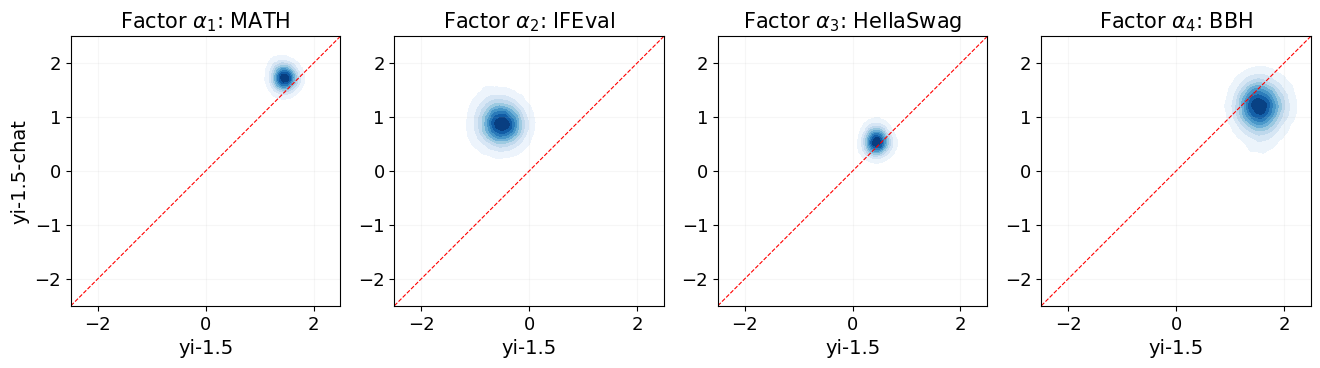

In [69]:
min_val = -2.5
max_val = 2.5

num_plots = K_opt[j]

# Create a row of subplots with shared tick positions
fig, axes = plt.subplots(1, num_plots, figsize=(4*num_plots, 3.5), 
                         sharex=True, sharey=True, squeeze=False)
axes = axes.flatten()  # Ensure we have a 1D array of axes

for k in range(num_plots):
    A = np.hstack((
        np.vstack(alphas[fs[0]])[:, k][:, None],
        np.vstack(alphas[fs[1]])[:, k][:, None]
    ))
    ax = axes[k]
    sns.kdeplot(x=A[:, 0], y=A[:, 1], cmap="Blues", fill=True, ax=ax)
    
    # Red dashed line
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=.8)
    
    # Set axis labels and title
    ax.set_xlabel(f"{f1}", fontsize=fontsize+1)
    ax.set_ylabel(f"{f2}", fontsize=fontsize+1)
    ax.set_title(f'Factor $\\alpha_{{{k+1}}}$: {[Y_names_tidy[s] for s in Y_names[j]][:K_opt[j]][k]}', 
                 fontsize=fontsize+2)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # Ensure tick labels are visible on each subplot
    ax.tick_params(axis='x', labelsize=fontsize, labelbottom=True)
    ax.tick_params(axis='y', labelsize=fontsize, labelleft=True)
    ax.grid(alpha=0.1)

# Adjust horizontal spacing between plots
plt.subplots_adjust(wspace=0.2)
plt.savefig(f'plots/comparing_factors_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Optimal scaling

In [437]:
def make_joint_latex_table(
    t1, t2, t3, t4,
    group_names=[Y_names_tidy[y] for y in Y_names[j][:K_opt[j]]],
    caption="Optimal allocation across skills for various compute budgets.",
    label="tab:opt_full",
    flops_header=r"\textbf{FLOPs (1e19)",
    inner_headers=(r"\textbf{Params (B)}", r"\textbf{Tokens (T)}"),
    decimals=2,
):
    """
    Merge four (n,3) arrays [FLOPs, Params, Tokens] into one LaTeX table:
    1 shared FLOPs column + 2 columns per table = 9 columns total.
    """

    tables = [np.asarray(t, dtype=float) for t in (t1, t2, t3, t4)]
    nrows = tables[0].shape[0]

    # Validate shapes
    for i, t in enumerate(tables, 1):
        if t.ndim != 2 or t.shape[1] != 3:
            raise ValueError(f"Table {i} must have shape (n, 3): [FLOPs, Params, Tokens].")
        if t.shape[0] != nrows:
            raise ValueError("All tables must have the same number of rows (same FLOPs grid).")

    # Check FLOPs column alignment
    base_flops = tables[0][:, 0]
    for i in range(1, 4):
        if not np.allclose(base_flops, tables[i][:, 0], rtol=0, atol=1e-9):
            raise ValueError("First column (FLOPs) must match across all four tables.")

    # Formatting helpers
    fmt = f"{{:.{decimals}f}}".format

    def _tex_escape(s: str) -> str:
        return (s.replace("&", r"\&")
                 .replace("%", r"\%")
                 .replace("$", r"\$")
                 .replace("#", r"\#")
                 .replace("_", r"\_")
                 .replace("{", r"\{")
                 .replace("}", r"\}")
                 .replace("~", r"\textasciitilde{}")
                 .replace("^", r"\textasciicircum{}"))

    gnames = [_tex_escape(str(x)) for x in group_names]
    ih1, ih2 = inner_headers

    # Column alignment: c | cc | cc | cc | cc
    align = "c|" + "cc|" * 3 + "cc"

    # Build header lines (use only plain r-strings when no interpolation is needed)
    group_parts = []
    for k, name in enumerate(gnames):
        bar = "|" if k < len(gnames) - 1 else ""
        group_parts.append(rf"\multicolumn{{2}}{{c{bar}}}{{\textbf{{{name}}}}}")
    header_top = rf"{flops_header} & " + " & ".join(group_parts) + r" \\"
    header_sub = " & " + " & ".join([rf"{ih1} & {ih2}"] * 4) + r" \\"

    # Body rows
    body_lines = []
    for r in range(nrows):
        row = [fmt(base_flops[r])]
        for t in tables:
            row.append(fmt(t[r, 1]))  # Params
            row.append(fmt(t[r, 2]))  # Tokens
        body_lines.append(" & ".join(row) + r" \\")

    # Assemble LaTeX table
    latex = [
        r"\begin{table}[h!]",
        r"\centering",
        r"\footnotesize",
        rf"\begin{{tabular}}{{{align}}}",  # <-- doubled braces around 'tabular'
        r"\toprule",
        header_top,
        header_sub,
        r"\midrule",
        *body_lines,
        r"\bottomrule",
        r"\end{tabular}",
        rf"\caption{{{_tex_escape(caption)}}}",
        rf"\label{{{_tex_escape(label)}}}",
        r"\end{table}",
    ]
    return "\n".join(latex)

In [ ]:
j=0

In [386]:
X = stds[j]*Xs[j]+mus[j]

In [399]:
Cs = [X.min(0)[:-1].sum(-1),X.max(0)[:-1].sum(-1)]
Cs = np.linspace(Cs[0], Cs[1], 10)

In [423]:
argmaxs = {}
for k in range(K_opt[j]):
    argmaxs[k] = []
    beta = models[j][K_opt[j]].beta[:,k]/stds[j]
    for c in Cs:
        
        def g(u,c):
            return -beta[2]*u**2 + (beta[0]-beta[1]+beta[2]*c)*u
        
        U = np.linspace(max(c-X.max(0)[1],X.min(0)[0]), min(c-X.min(0)[1],X.max(0)[0]), 1000)
        assert U[0]<=U[1]
        argmax_u = U[np.argmax([g(u,c) for u in U])]
        argmax_v = c - argmax_u
    
        argmaxs[k].append([np.exp(argmax_u), np.exp(argmax_v)])
    argmaxs[k] = np.array(argmaxs[k])
    argmaxs[k] = np.hstack((100*6*np.prod(argmaxs[k], -1)[:,None], argmaxs[k]))

In [438]:
print(make_joint_latex_table(argmaxs[0], argmaxs[1], argmaxs[2], argmaxs[3]))

\begin{table}[h!]
\centering
\footnotesize
\begin{tabular}{c|cc|cc|cc|cc}
\toprule
\textbf{FLOPs (1e19) & \multicolumn{2}{c|}{\textbf{MATH}} & \multicolumn{2}{c|}{\textbf{IFEval}} & \multicolumn{2}{c|}{\textbf{HellaSwag}} & \multicolumn{2}{c}{\textbf{BBH}} \\
 & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} \\
\midrule
6.30 & 0.07 & 0.15 & 0.07 & 0.15 & 0.07 & 0.15 & 0.07 & 0.15 \\
25.15 & 0.07 & 0.60 & 0.13 & 0.32 & 0.28 & 0.15 & 0.28 & 0.15 \\
100.37 & 0.07 & 2.39 & 0.26 & 0.63 & 1.12 & 0.15 & 1.12 & 0.15 \\
400.62 & 0.07 & 9.54 & 0.53 & 1.27 & 4.45 & 0.15 & 4.45 & 0.15 \\
1599.05 & 0.18 & 15.00 & 1.06 & 2.52 & 17.77 & 0.15 & 17.77 & 0.15 \\
6382.53 & 0.71 & 15.00 & 2.10 & 5.05 & 70.92 & 0.15 & 70.92 & 0.15 \\
25475.55 & 2.83 & 15.00 & 4.22 & 10.06 & 180.00 & 0.24 & 180.00 & 0.24 \\
101684.33 & 11.30 & 15.00 & 11.30 & 15.00 & 180.00 & 0.94 & 180.00 & 0.94 \\